# Expected Points Models by Position

Linear regression models predicting next gameweek's points from:
- Average points per game (season to date)
- Average points per game (last 10 featured games)
- Fixture difficulty (easy/medium/hard)
- Home/Away

Walk-forward validation: GW 28-33 test, GW 1-27+ train (expanding window)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print('Imports successful!')

Imports successful!


## 1. Load Data

In [2]:
# Load all gameweek CSVs
data_dir = Path('data')
csv_files = sorted(data_dir.glob('player_stats_gw*.csv'))

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Sort by player and gameweek
df = df.sort_values(['player_id', 'gameweek']).reset_index(drop=True)

print(f'Loaded {len(csv_files)} gameweeks')
print(f'Total rows: {len(df):,}')
print(f'Gameweeks: {df["gameweek"].min()}-{df["gameweek"].max()}')
print(f'\nPositions: {df["position"].unique()}')

Loaded 34 gameweeks
Total rows: 88,248
Gameweeks: 1-34

Positions: <StringArray>
['MID', 'GK', 'FWD', 'DEF']
Length: 4, dtype: str


In [3]:
df[df['display_name'] == 'L. Wing'].tail(10)

,player_id,first_name,last_name,display_name,position,squad_id,gameweek,opponent_id,opponent_name,fixture_difficulty,...,penalty_saves,clean_sheet,goals_conceded,clearances,blocks,tackles,interceptions,key_passes,shots_on_target,points
38579,432647,Lewis,Wing,L. Wing,MID,108,28,2623.0,AFC Wim,medium,...,0,0,0,0,0,0,0,1,0,2
38580,432647,Lewis,Wing,L. Wing,MID,108,29,112.0,Wycombe,medium,...,0,0,0,0,0,0,2,2,0,10
38581,432647,Lewis,Wing,L. Wing,MID,108,29,30.0,Bolton,hard,...,0,0,0,0,0,0,2,2,0,10
38582,432647,Lewis,Wing,L. Wing,MID,108,30,50.0,Port Vale,easy,...,0,0,0,0,0,0,0,2,1,10
38583,432647,Lewis,Wing,L. Wing,MID,108,31,55.0,Bradford,hard,...,0,0,0,0,0,0,2,2,0,7
38584,432647,Lewis,Wing,L. Wing,MID,108,32,77.0,Mansfield,medium,...,0,0,0,0,0,0,2,3,0,10
38585,432647,Lewis,Wing,L. Wing,MID,108,32,102.0,Luton,medium,...,0,0,0,0,0,0,2,3,0,10
38586,432647,Lewis,Wing,L. Wing,MID,108,33,76.0,Plymouth,hard,...,0,0,0,0,0,0,1,4,0,9
38587,432647,Lewis,Wing,L. Wing,MID,108,33,587.0,Burton,easy,...,0,0,0,0,0,0,1,4,0,9
38588,432647,Lewis,Wing,L. Wing,MID,108,34,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,0,4


In [4]:
df[df['display_name'] == 'L. Wing']['points'].mean()

np.float64(8.256410256410257)

## 2. Build Rolling Features

For each player at gameweek N:
- `avg_pts_season`: mean points in GW 1..N-1 where player featured (mins > 0)
- `avg_pts_last_10`: mean points in last 10 featured games before GW N

In [5]:
# Create a featured-games-only view for rolling calculations
df_featured = df[df['minutes_played'] > 0].copy().sort_values(['player_id', 'gameweek']).reset_index(drop=True)

# For avg_pts_season: cumulative mean of all prior featured games per player
# Must use transform() so the expanding/rolling stays within each player group
df_featured['avg_pts_season'] = df_featured.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)

# For last-10 avg: rolling mean of last 10 featured games per player
df_featured['avg_pts_last_10'] = df_featured.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)

# Merge back to main dataframe — include opponent_id to avoid cartesian product with multiple games per gameweek
df = df.merge(
    df_featured[['player_id', 'gameweek', 'opponent_id', 'avg_pts_season', 'avg_pts_last_10']],
    on=['player_id', 'gameweek', 'opponent_id'],
    how='left'
)

# For non-featured games, forward-fill season avg (carry previous value), use season avg for last_10 as fallback
df['avg_pts_season'] = df.groupby('player_id')['avg_pts_season'].ffill().fillna(0)
df['avg_pts_last_10'] = df['avg_pts_last_10'].fillna(df['avg_pts_season'])

print(f'\nSample rows with rolling features:')
print(df[['player_id', 'gameweek', 'position', 'points', 'avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty', 'is_home']].head(15))


Sample rows with rolling features:
    player_id  gameweek position  points  avg_pts_season  avg_pts_last_10  \
0        2076        23      MID       0        0.000000         0.000000   
1        3774         1       GK       0        0.000000         0.000000   
2        3774         2       GK       0        0.000000         0.000000   
3        3774         3       GK       0        0.000000         0.000000   
4        3774         4       GK       0        0.000000         0.000000   
5        3774         5       GK       0        0.000000         0.000000   
6        3774         6       GK       3        0.000000         0.000000   
7        3774         7       GK       3        3.000000         3.000000   
8        3774         8       GK       2        3.000000         3.000000   
9        3774         9       GK       7        2.666667         2.666667   
10       3774        10       GK       2        3.750000         3.750000   
11       3774        11       GK       1

## 3. Encode Categorical Features

In [6]:
# Encode fixture difficulty
difficulty_map = {'easy': 0, 'medium': 1, 'hard': 2}
df['fixture_difficulty_encoded'] = df['fixture_difficulty'].map(difficulty_map).fillna(1)  # Default to medium

# Encode is_home (H=1, A=0)
df['is_home_binary'] = (df['is_home'] == 'H').astype(int)

print('Encoded features:')
print(df[['fixture_difficulty', 'fixture_difficulty_encoded', 'is_home', 'is_home_binary']].head(10))

Encoded features:
  fixture_difficulty  fixture_difficulty_encoded is_home  is_home_binary
0               hard                         2.0       A               0
1             medium                         1.0       A               0
2               easy                         0.0       H               1
3             medium                         1.0       H               1
4               easy                         0.0       A               0
5               hard                         2.0       H               1
6               hard                         2.0       A               0
7               easy                         0.0       H               1
8             medium                         1.0       A               0
9               hard                         2.0       H               1


## 4. Filter to GW 20+ (ensure sufficient history)

In [ ]:
# Filter to GW >= 20, featured games only (minutes_played > 0)
# We only train/predict on games where the player actually played.
# Including non-featured rows (0 mins, 0 pts) would teach the model that
# good players regularly score 0, dragging all predictions down.
df_train = df[(df['gameweek'] >= 20) & (df['minutes_played'] > 0)].copy()
df_train = df_train.dropna(subset=['avg_pts_season', 'avg_pts_last_10'])

print(f'Rows with GW >= 20 (featured only): {len(df_train):,}')
print(f'Gameweeks: {df_train["gameweek"].min()}-{df_train["gameweek"].max()}')
print(f'Positions: {df_train["position"].unique()}')

## 5. Walk-Forward Validation (GW 28-33)

For each test gameweek, train on all prior data and predict that gameweek

In [8]:
test_gws = [28, 29, 30, 31, 32, 33]
positions = ['GK', 'DEF', 'MID', 'FWD']

# Storage for results
all_predictions = []
all_actuals = []
model_results = {}

for position in positions:
    print(f'\n=== {position} ===')
    model_results[position] = {'baseline': [], 'full': []}
    
    for test_gw in test_gws:
        # Split: train on all data before test_gw
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            print(f'  GW {test_gw}: Skipped (insufficient data)')
            continue
        
        # Features
        X_train_full = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_train_base = train_data[['avg_pts_season']]
        y_train = train_data['points']
        
        X_test_full = test_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_test_base = test_data[['avg_pts_season']]
        y_test = test_data['points']
        
        # Train baseline (avg_pts_season only)
        model_base = LinearRegression()
        model_base.fit(X_train_base, y_train)
        y_pred_base = model_base.predict(X_test_base)
        mae_base = mean_absolute_error(y_test, y_pred_base)
        mse_base = mean_squared_error(y_test, y_pred_base)
        rmse_base = np.sqrt(mse_base)
        r2_base = r2_score(y_test, y_pred_base)
        
        # Train full model
        model_full = LinearRegression()
        model_full.fit(X_train_full, y_train)
        y_pred_full = model_full.predict(X_test_full)
        mae_full = mean_absolute_error(y_test, y_pred_full)
        mse_full = mean_squared_error(y_test, y_pred_full)
        rmse_full = np.sqrt(mse_full)
        r2_full = r2_score(y_test, y_pred_full)
        
        # Store results
        model_results[position]['baseline'].append({'gw': test_gw, 'mae': mae_base, 'mse': mse_base, 'rmse': rmse_base, 'r2': r2_base})
        model_results[position]['full'].append({'gw': test_gw, 'mae': mae_full, 'mse': mse_full, 'rmse': rmse_full, 'r2': r2_full})
        
        print(f'  GW {test_gw} (train: {len(train_data)}, test: {len(test_data)})')
        print(f'    Baseline - MAE: {mae_base:.3f}, RMSE: {rmse_base:.3f}, RÂ²: {r2_base:.3f}')
        print(f'    Full     - MAE: {mae_full:.3f}, RMSE: {rmse_full:.3f}, RÂ²: {r2_full:.3f}')
        
        # Collect for aggregate metrics
        all_predictions.append(y_pred_full)
        all_actuals.append(y_test.values)

print('\nWalk-forward validation complete!')


=== GK ===
  GW 28 (train: 2250, test: 285)
    Baseline - MAE: 1.619, RMSE: 2.756, RÂ²: 0.218
    Full     - MAE: 1.611, RMSE: 2.730, RÂ²: 0.233
  GW 29 (train: 2535, test: 303)
    Baseline - MAE: 1.416, RMSE: 2.232, RÂ²: 0.238
    Full     - MAE: 1.424, RMSE: 2.263, RÂ²: 0.216
  GW 30 (train: 2838, test: 343)
    Baseline - MAE: 1.282, RMSE: 2.020, RÂ²: 0.146
    Full     - MAE: 1.268, RMSE: 1.999, RÂ²: 0.164
  GW 31 (train: 3181, test: 274)
    Baseline - MAE: 1.521, RMSE: 2.378, RÂ²: 0.209
    Full     - MAE: 1.536, RMSE: 2.385, RÂ²: 0.205
  GW 32 (train: 3455, test: 364)
    Baseline - MAE: 1.278, RMSE: 2.056, RÂ²: 0.170
    Full     - MAE: 1.288, RMSE: 2.064, RÂ²: 0.163
  GW 33 (train: 3819, test: 382)
    Baseline - MAE: 1.506, RMSE: 2.288, RÂ²: 0.253
    Full     - MAE: 1.506, RMSE: 2.296, RÂ²: 0.247

=== DEF ===
  GW 28 (train: 7491, test: 961)
    Baseline - MAE: 2.117, RMSE: 2.867, RÂ²: 0.156
    Full     - MAE: 2.102, RMSE: 2.830, RÂ²: 0.177
  GW 29 (train: 8452, test: 10

## 6. Aggregate Results

In [9]:
# Combine all predictions and actuals
all_preds = np.concatenate(all_predictions)
all_acts = np.concatenate(all_actuals)

# Aggregate metrics
results_rows = []

for position in positions:
    for model_type in ['baseline', 'full']:
        results = model_results[position][model_type]
        if len(results) == 0:
            continue
        
        mae = np.mean([r['mae'] for r in results])
        mse = np.mean([r['mse'] for r in results])
        rmse = np.mean([r['rmse'] for r in results])
        r2 = np.mean([r['r2'] for r in results])
        
        results_rows.append({
            'Position': position,
            'Model': model_type.capitalize(),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'RÂ²': r2
        })

results_df = pd.DataFrame(results_rows)

print('\n=== AGGREGATE RESULTS (GW 28-33) ===')
print(results_df.to_string(index=False))

# Overall metrics
mae_all = mean_absolute_error(all_acts, all_preds)
mse_all = mean_squared_error(all_acts, all_preds)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(all_acts, all_preds)

print(f'\n=== OVERALL (Full Model, All Positions, GW 28-33) ===')
print(f'MAE:  {mae_all:.3f}')
print(f'MSE:  {mse_all:.3f}')
print(f'RMSE: {rmse_all:.3f}')
print(f'RÂ²:   {r2_all:.3f}')


=== AGGREGATE RESULTS (GW 28-33) ===
Position    Model      MAE      MSE     RMSE      RÂ²
      GK Baseline 1.436836 5.295048 2.288160 0.205759
      GK     Full 1.438628 5.298231 2.289501 0.204718
     DEF Baseline 2.094574 8.719874 2.947210 0.143913
     DEF     Full 2.095492 8.649414 2.935025 0.150988
     MID Baseline 1.681339 6.972264 2.640097 0.203352
     MID     Full 1.678662 6.888244 2.623978 0.213042
     FWD Baseline 1.585103 6.897114 2.620674 0.139180
     FWD     Full 1.579451 6.806842 2.603122 0.150889

=== OVERALL (Full Model, All Positions, GW 28-33) ===
MAE:  1.763
MSE:  7.265
RMSE: 2.695
RÂ²:   0.181


## 7. Visualisation: Predicted vs Actual by Position

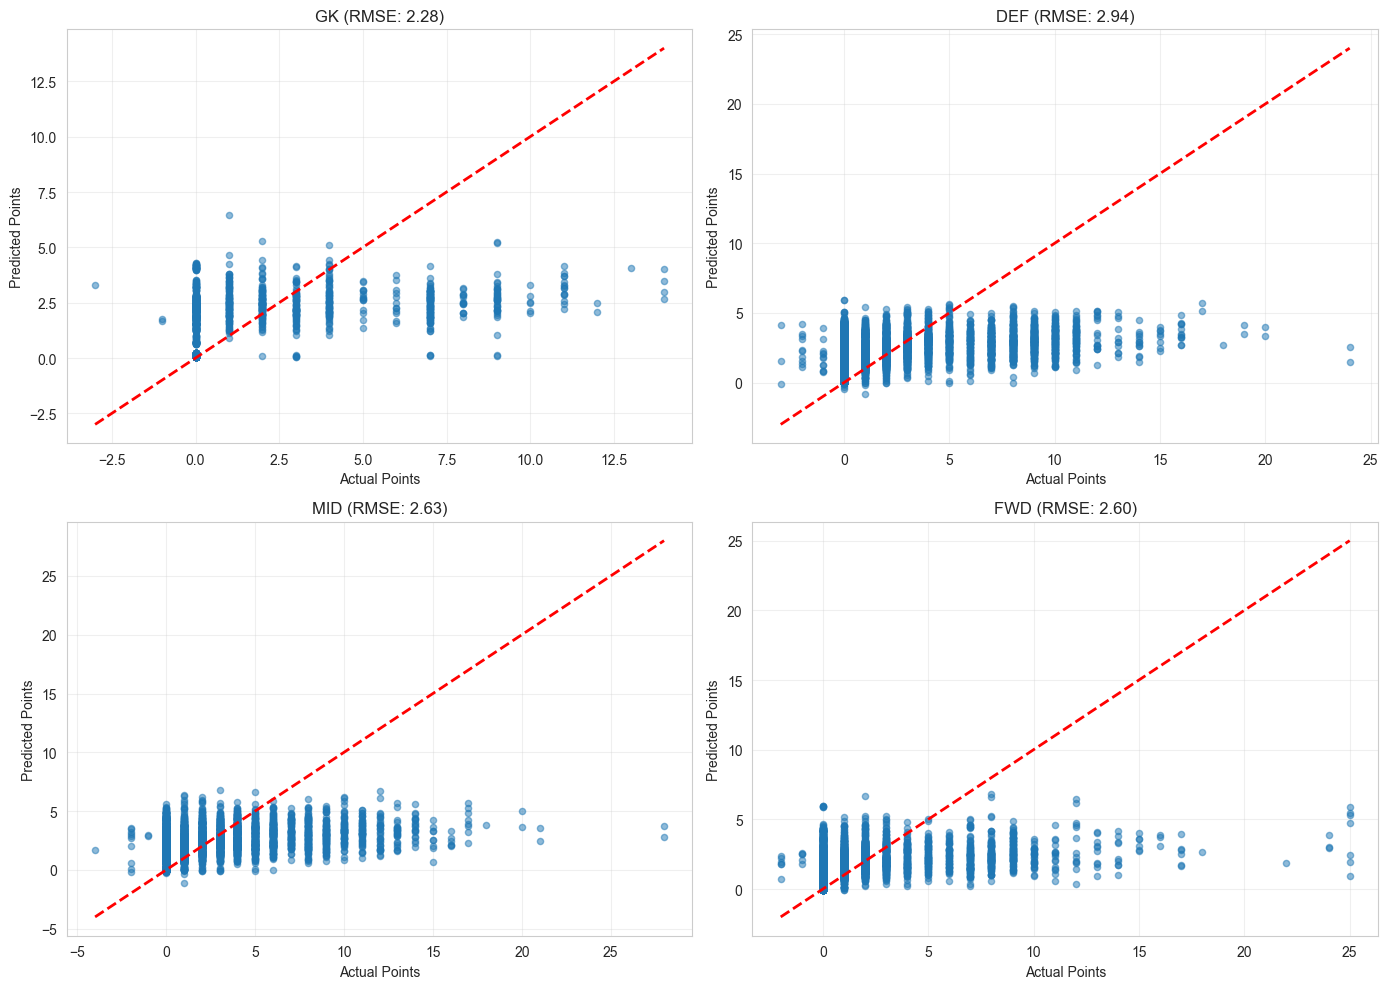

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, position in enumerate(positions):
    # Collect all predictions and actuals for this position across walk-forward folds
    position_preds = []
    position_acts = []
    
    for test_gw in test_gws:
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            continue
        
        X_train = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_train = train_data['points']
        X_test = test_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_test = test_data['points']
        
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        position_preds.extend(y_pred)
        position_acts.extend(y_test.values)
    
    if len(position_preds) == 0:
        continue
    
    position_preds = np.array(position_preds)
    position_acts = np.array(position_acts)
    
    ax = axes[idx]
    ax.scatter(position_acts, position_preds, alpha=0.5, s=20)
    ax.plot([position_acts.min(), position_acts.max()], [position_acts.min(), position_acts.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Points')
    ax.set_ylabel('Predicted Points')
    ax.set_title(f'{position} (RMSE: {np.sqrt(mean_squared_error(position_acts, position_preds)):.2f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Comparison: Improvement from Full vs Baseline

In [11]:
comparison_rows = []

for position in positions:
    baseline_rmses = [r['rmse'] for r in model_results[position]['baseline']]
    full_rmses = [r['rmse'] for r in model_results[position]['full']]
    
    if len(baseline_rmses) == 0:
        continue
    
    avg_baseline_rmse = np.mean(baseline_rmses)
    avg_full_rmse = np.mean(full_rmses)
    improvement = ((avg_baseline_rmse - avg_full_rmse) / avg_baseline_rmse) * 100
    
    comparison_rows.append({
        'Position': position,
        'Baseline RMSE': avg_baseline_rmse,
        'Full RMSE': avg_full_rmse,
        'Improvement %': improvement
    })

comparison_df = pd.DataFrame(comparison_rows)

print('\n=== IMPROVEMENT: Full Model vs Baseline ===')
print(comparison_df.to_string(index=False))
print(f'\nAverage improvement: {comparison_df["Improvement %"].mean():.2f}%')


=== IMPROVEMENT: Full Model vs Baseline ===
Position  Baseline RMSE  Full RMSE  Improvement %
      GK       2.288160   2.289501      -0.058619
     DEF       2.947210   2.935025       0.413441
     MID       2.640097   2.623978       0.610525
     FWD       2.620674   2.603122       0.669753

Average improvement: 0.41%


## 9. Case Study: Lewis Wing Predictions (GW 28-33)

## Helper: Player Prediction Function

In [12]:
def player_predictions(player_name, test_gws=[28, 29, 30, 31, 32, 33]):
    """
    Generate and display predictions for a player across test gameweeks.
    
    Args:
        player_name: Display name of player (e.g., 'L. Wing')
        test_gws: List of gameweeks to predict for
    """
    # Find player
    player_data = df_train[df_train['display_name'].str.contains(player_name, case=False, na=False)]
    
    if len(player_data) == 0:
        print(f'Player "{player_name}" not found')
        return
    
    player_id = player_data['player_id'].iloc[0]
    position = player_data['position'].iloc[0]
    full_name = player_data['display_name'].iloc[0]
    
    print(f'Found: {full_name} (ID: {player_id}, Position: {position})\n')
    
    # Get player's test data (GW 28-33)
    player_test = df_train[(df_train['player_id'] == player_id) & (df_train['gameweek'].isin(test_gws))]
    
    if len(player_test) == 0:
        print('No data for test gameweeks')
        return
    
    # Train model on his position for GW 1-27
    train_data = df_train[(df_train['gameweek'] < 28) & (df_train['position'] == position)]
    X_train = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
    y_train = train_data['points']
    
    model = LinearRegression().fit(X_train, y_train)
    
    # Get predictions
    X_player = player_test[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
    y_pred = model.predict(X_player)
    y_actual = player_test['points'].values
    
    # Build results table
    results = []
    for idx, (_, row) in enumerate(player_test[['gameweek', 'opponent_name', 'fixture_difficulty', 'is_home', 'avg_pts_season', 'avg_pts_last_10', 'points']].iterrows()):
        results.append({
            'GW': int(row['gameweek']),
            'Opponent': row['opponent_name'],
            'Fixture': row['fixture_difficulty'],
            'H/A': row['is_home'],
            'Avg Pts (Season)': f"{row['avg_pts_season']:.2f}",
            'Avg Pts (Last 6)': f"{row['avg_pts_last_10']:.2f}",
            'Predicted': f"{y_pred[idx]:.1f}",
            'Actual': int(row['points'])
        })
    
    results_df = pd.DataFrame(results)
    
    print(f'=== {full_name}: Predictions GW 28-33 ===')
    print(results_df.to_string(index=False))
    
    # Summary metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    print(f'\nMAE:  {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'Total predicted: {y_pred.sum():.0f}')
    print(f'Total actual:    {y_actual.sum()}')

# Example usage:
player_predictions('L. Wing')

Found: L. Wing (ID: 432647, Position: MID)

=== L. Wing: Predictions GW 28-33 ===
 GW  Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28     Wigan    easy   A             8.54             8.60       5.7       2
 28   AFC Wim  medium   A             8.31             8.60       5.7       2
 29   Wycombe  medium   H             8.10             7.30       5.0      10
 29    Bolton    hard   H             8.16             6.40       4.5      10
 30 Port Vale    easy   A             8.22             5.50       4.0      10
 31  Bradford    hard   H             8.27             6.20       4.4       7
 32 Mansfield  medium   A             8.24             6.60       4.5      10
 32     Luton  medium   A             8.29             7.40       5.0      10
 33  Plymouth    hard   H             8.33             7.80       5.3       9
 33    Burton    easy   A             8.35             8.10       5.4       9

MAE:  4.44
RMSE: 4.57
Total predicted: 49
Total actual:    

In [13]:
player_predictions('S. Bradley')

Found: S. Bradley (ID: 90495, Position: DEF)

=== S. Bradley: Predictions GW 28-33 ===
 GW     Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28     Plymouth    hard   A             5.86             6.20       3.6       3
 29       Bolton    hard   H             5.76             6.20       3.8       3
 29  Northampton    easy   H             5.67             5.40       3.7       3
 30    Mansfield  medium   A             5.58             5.10       3.2       9
 31    Blackpool    easy   H             5.69             5.40       3.7       9
 32       Exeter    easy   A             5.79             5.60       3.6       9
 32      Cardiff    hard   A             5.88             5.80       3.4       9
 33    Stockport    hard   H             5.97             6.40       3.9       9
 33 Huddersfield  medium   A             6.06             6.80       4.1       9

MAE:  3.79
RMSE: 4.38
Total predicted: 33
Total actual:    63
